# Environment

## Imports

In [39]:
import distinctipy
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

import scanpy as sc
import anndata as an

import muon as mu
from muon import atac as ac

## Global variables

In [47]:
colors = distinctipy.get_colors(151)
cmap = ListedColormap(colors)
palette = sns.color_palette(colors)

## Load data

In [2]:
adata = sc.read_h5ad("results/pseudobulk/lvl5/combined.h5ad")
adata.layers["sum"] = np.nan_to_num(adata.layers["sum"], nan=0)
adata.layers["mean"] = np.nan_to_num(adata.layers["mean"], nan=0)
adata

AnnData object with n_obs × n_vars = 5431 × 1142057
    obs: 'sample_id', 'celltype', 'n_obs_aggregated'
    layers: 'mean', 'sum'

# Process

## QC

<Axes: xlabel='n_obs_aggregated', ylabel='Count'>

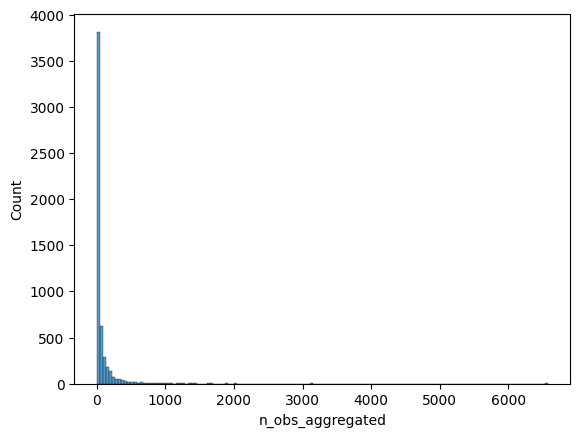

In [3]:
sns.histplot(adata.obs.n_obs_aggregated)

Add total counts per cell and per peak

In [4]:
adata.obs["total_counts_sum"] = adata.layers["sum"].sum(axis=1)
adata.obs["total_counts_mean"] = adata.layers["mean"].sum(axis=1)

adata.var["total_counts_sum"] = adata.layers["sum"].sum(axis=0)
adata.var["total_counts_mean"] = adata.layers["mean"].sum(axis=0)
adata

AnnData object with n_obs × n_vars = 5431 × 1142057
    obs: 'sample_id', 'celltype', 'n_obs_aggregated', 'total_counts_sum', 'total_counts_mean'
    var: 'total_counts_sum', 'total_counts_mean'
    layers: 'mean', 'sum'

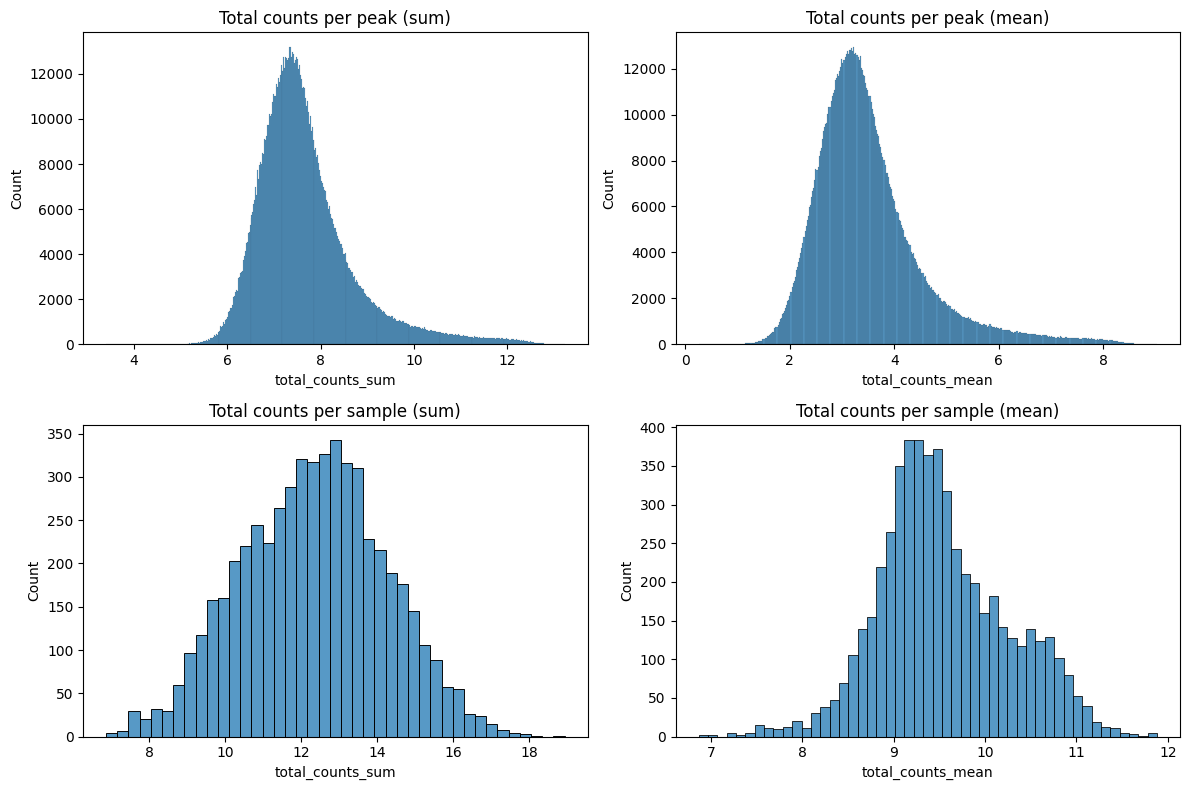

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(np.log1p(adata.var.total_counts_sum), ax=axes[0, 0])
sns.histplot(np.log1p(adata.var.total_counts_mean), ax=axes[0, 1])
axes[0, 0].set_title("Total counts per peak (sum)")
axes[0, 1].set_title("Total counts per peak (mean)")

sns.histplot(np.log1p(adata.obs.total_counts_sum), ax=axes[1, 0])
sns.histplot(np.log1p(adata.obs.total_counts_mean), ax=axes[1, 1])
axes[1, 0].set_title("Total counts per sample (sum)")
axes[1, 1].set_title("Total counts per sample (mean)")

plt.tight_layout()

Let's filter pseudobulk samples with less than 20 cells aggregated, as these are likely to be noisy

In [6]:
before_filtering = adata.obs.groupby("celltype").agg({"n_obs_aggregated": ["sum", "count"]})
before_filtering.columns = ["total_cells", "n_pb_samples"]

filtered = adata[adata.obs.n_obs_aggregated < 5].obs.groupby("celltype").agg({"n_obs_aggregated": ["sum", "count"]})
filtered.columns = ["total_cells_filtered", "n_pb_samples_filtered"]

summary = before_filtering.join(filtered, how="left").fillna(0)
summary["percent_cells_filtered"] = np.round(summary["total_cells_filtered"] / summary["total_cells"] * 100, 2)
summary["percent_samples_filtered"] = np.round(summary["n_pb_samples_filtered"] / summary["n_pb_samples"] * 100, 2)
summary = summary.sort_values("percent_samples_filtered", ascending=False)
summary.head(20)

/tmp/ipykernel_352920/77867349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  before_filtering = adata.obs.groupby("celltype").agg({"n_obs_aggregated": ["sum", "count"]})
/tmp/ipykernel_352920/77867349.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered = adata[adata.obs.n_obs_aggregated < 5].obs.groupby("celltype").agg({"n_obs_aggregated": ["sum", "count"]})


,total_cells,n_pb_samples,total_cells_filtered,n_pb_samples_filtered,percent_cells_filtered,percent_samples_filtered
celltype,,,,,,
DC1,2,2,2.0,2.0,100.00,100.00
excitatory neuron midbrain,8,6,8.0,6.0,100.00,100.00
retinal neural progenitors,700,26,37.0,23.0,5.29,88.46
DC2,74,26,41.0,22.0,55.41,84.62
myeloid progenitor,92,25,38.0,21.0,41.30,84.00
early lymphoid progenitor,336,31,44.0,26.0,13.10,83.87
excitatory neuron,101,24,33.0,20.0,32.67,83.33
promonocyte,310,40,63.0,31.0,20.32,77.50
enteric neuronal progenitor,28,11,9.0,8.0,32.14,72.73


In [7]:
ignore_celltypes = summary.index.tolist()[:10]
print(f"Number of pseudobulk samples filtered: {((adata.obs.n_obs_aggregated < 5) & ~(adata.obs.celltype.isin(ignore_celltypes))).sum()}")
adata = adata[(adata.obs.n_obs_aggregated >= 5) | (adata.obs.celltype.isin(ignore_celltypes))].copy()
adata

Number of pseudobulk samples filtered: 1274


AnnData object with n_obs × n_vars = 4157 × 1142057
    obs: 'sample_id', 'celltype', 'n_obs_aggregated', 'total_counts_sum', 'total_counts_mean'
    var: 'total_counts_sum', 'total_counts_mean'
    layers: 'mean', 'sum'

## Highly variable peaks

Normalise for sequence depth and log-transform

In [8]:
adata.layers["log_normsum"] = adata.layers["sum"].copy()
sc.pp.normalize_total(adata, target_sum=1e4, layer="log_normsum")
sc.pp.log1p(adata, layer="log_normsum")

In [9]:
adata.layers["log_normmean"] = adata.layers["mean"].copy()
sc.pp.normalize_total(adata, target_sum=1e4, layer="log_normmean")
sc.pp.log1p(adata, layer="log_normmean")

In [10]:
sc.pp.highly_variable_genes(adata, layer="log_normsum", flavor="seurat")
adata_hv_sum = adata[:, adata.var.highly_variable].copy()
adata_hv_sum

AnnData object with n_obs × n_vars = 4157 × 35910
    obs: 'sample_id', 'celltype', 'n_obs_aggregated', 'total_counts_sum', 'total_counts_mean'
    var: 'total_counts_sum', 'total_counts_mean', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'mean', 'sum', 'log_normsum', 'log_normmean'

In [11]:
sc.pp.highly_variable_genes(adata, layer="log_normmean", flavor="seurat")
adata_hv_mean = adata[:, adata.var.highly_variable].copy()
adata_hv_mean

AnnData object with n_obs × n_vars = 4157 × 35910
    obs: 'sample_id', 'celltype', 'n_obs_aggregated', 'total_counts_sum', 'total_counts_mean'
    var: 'total_counts_sum', 'total_counts_mean', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'mean', 'sum', 'log_normsum', 'log_normmean'

## Embeddings

### SUM

Normalise with TF-IDF

In [12]:
ac.pp.tfidf(adata_hv_sum, scale_factor=1e4, from_layer="sum", to_layer="tfidf_sum")

In [13]:
adata_hv_sum.X = adata_hv_sum.layers["tfidf_sum"]

Calculate LSI embedding

In [14]:
ac.tl.lsi(adata_hv_sum, n_comps=50)
# adata_hv_sum.obsm['X_lsi'] = adata_hv_sum.obsm['X_lsi'][:,1:]
# adata_hv_sum.varm["LSI"] = adata_hv_sum.varm["LSI"][:,1:]
# adata_hv_sum.uns["lsi"]["stdev"] = adata_hv_sum.uns["lsi"]["stdev"][1:]

Calculate PCA embedding

In [15]:
sc.pp.pca(adata_hv_sum, n_comps=50, layer="tfidf_sum")
# adata_hv_sum.obsm['pca_sum'] = adata_hv_sum.obsm['pca_sum'][:,2:]
# adata_hv_sum.varm["pca_sum"] = adata_hv_sum.varm["LSI"][:,2:]
# adata_hv_sum.uns["pca_sum"]["variance"] = adata_hv_sum.uns["pca_sum"]["variance"][2:]
# adata_hv_sum.uns["pca_sum"]["variance_ratio"] = adata_hv_sum.uns["pca_sum"]["variance_ratio"][2:]

Calculate KNN graphs

In [16]:
sc.pp.neighbors(adata_hv_sum, use_rep="X_lsi", key_added="neighbors_lsi")
sc.pp.neighbors(adata_hv_sum, use_rep="X_pca", key_added="neighbors_pca")

Calculate UMAP embeddings

In [17]:
sc.tl.umap(adata_hv_sum, neighbors_key="neighbors_lsi", key_added="umap_lsi")
sc.tl.umap(adata_hv_sum, neighbors_key="neighbors_pca", key_added="umap_pca")

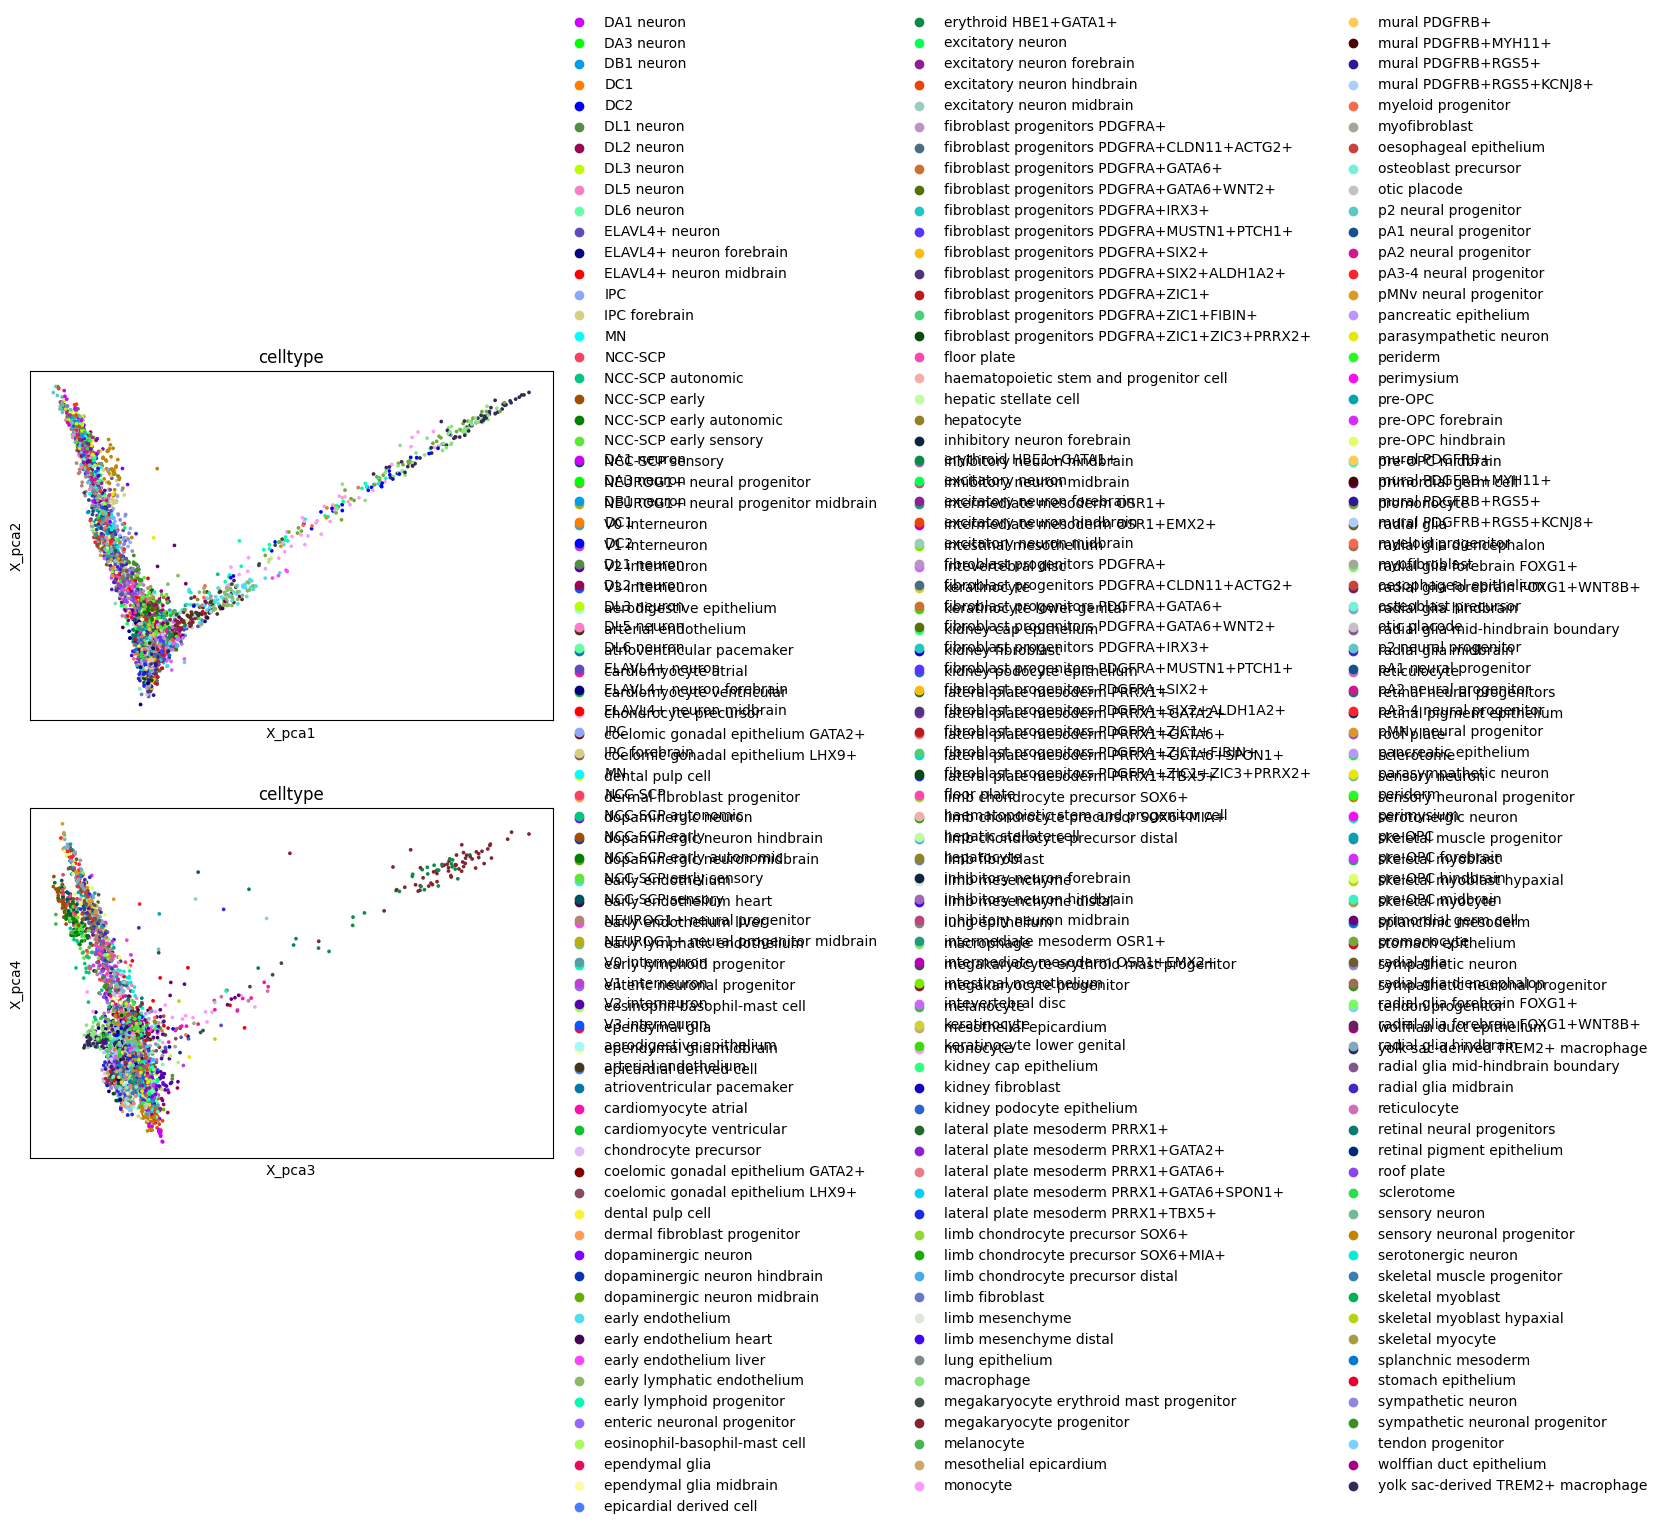

In [48]:
sc.pl.embedding(adata_hv_sum, basis="X_pca", color=["celltype"], ncols=1, components=["1,2", "3,4"], palette=palette)

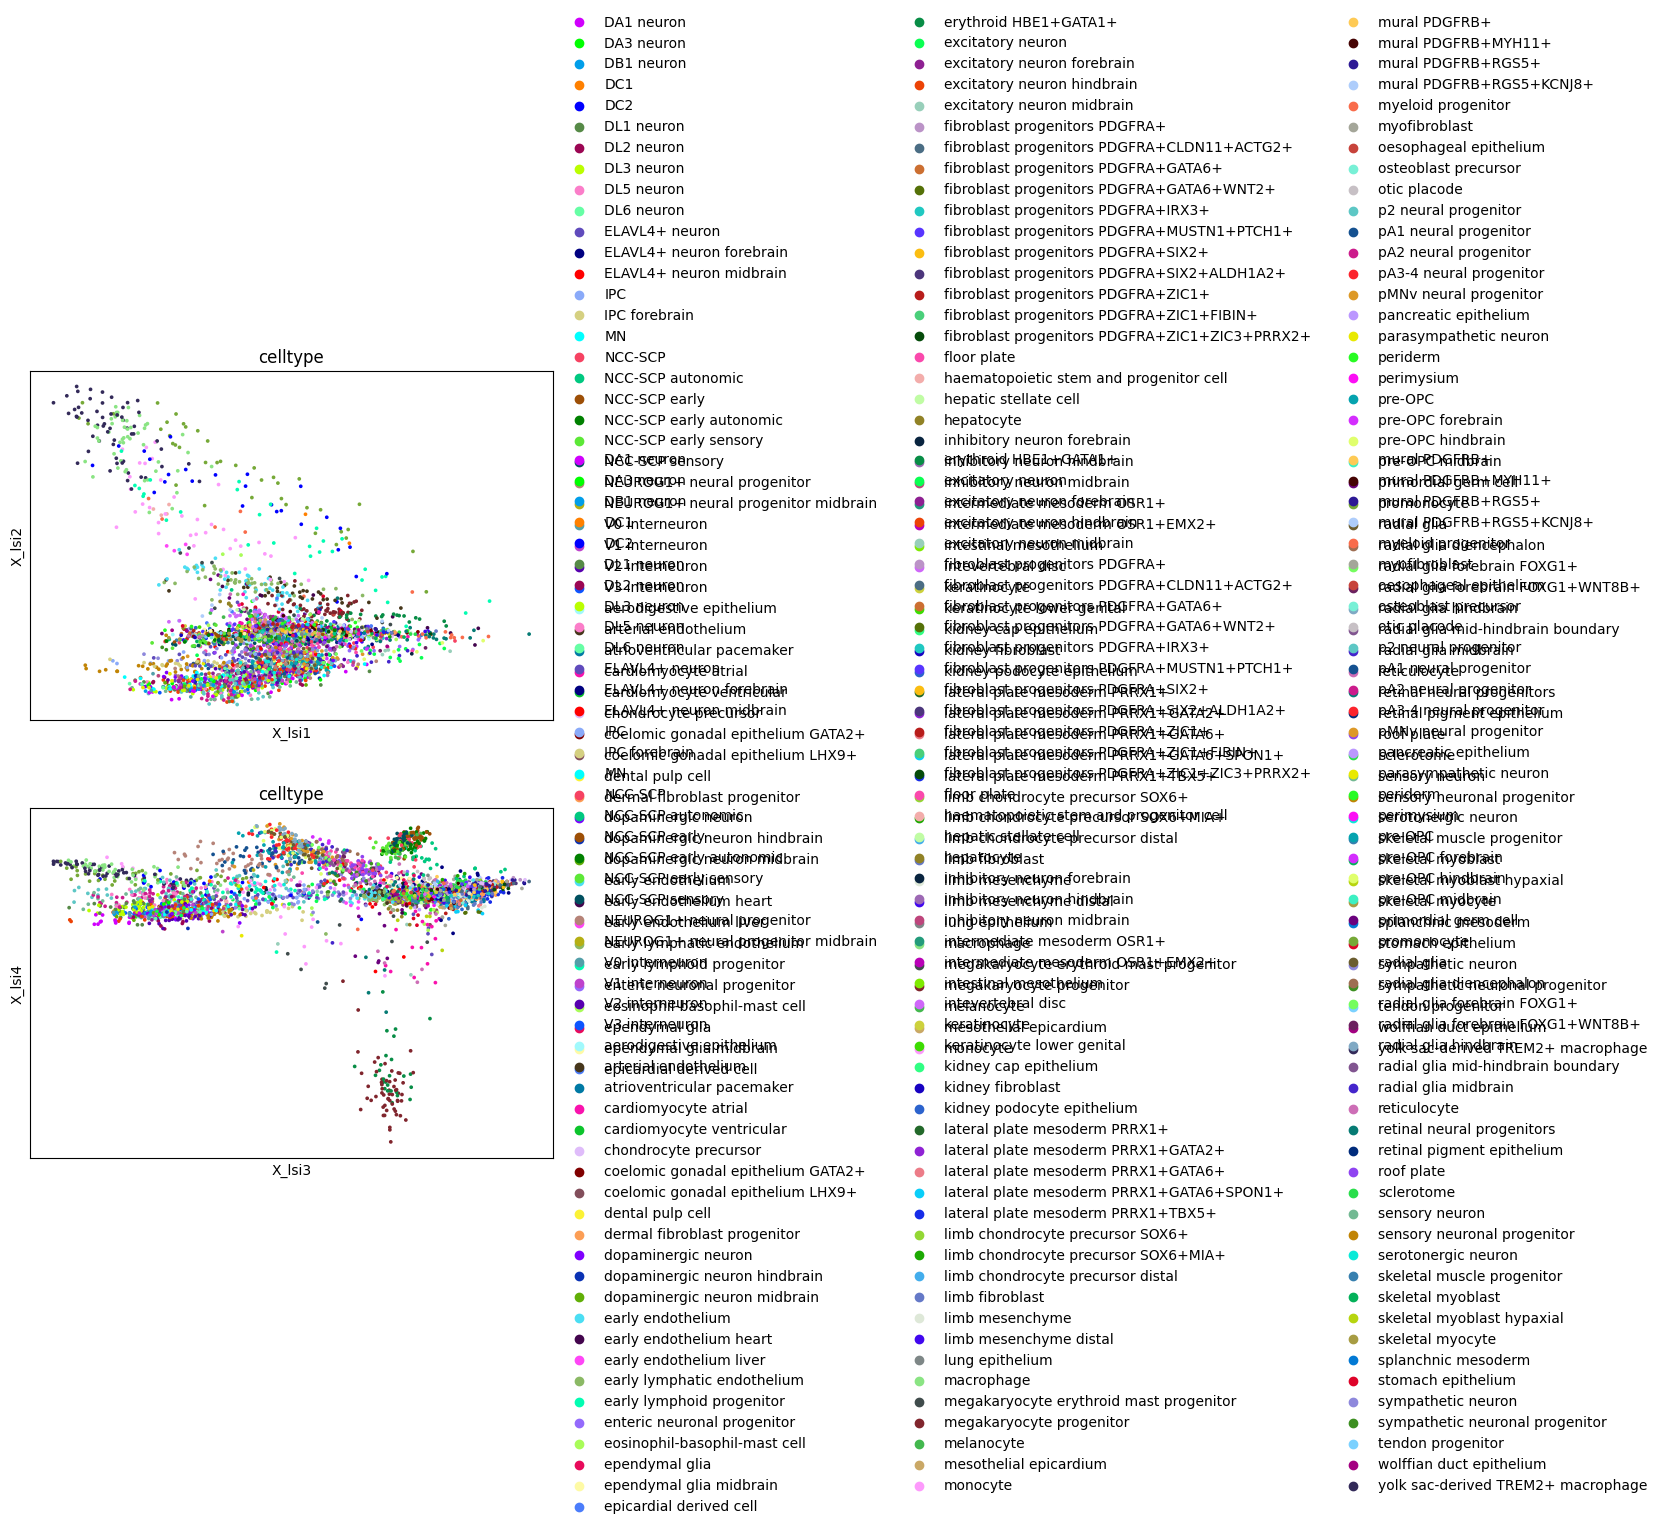

In [49]:
sc.pl.embedding(adata_hv_sum, basis="X_lsi", color=["celltype"], ncols=1, components=["1,2", "3,4"], palette=palette)

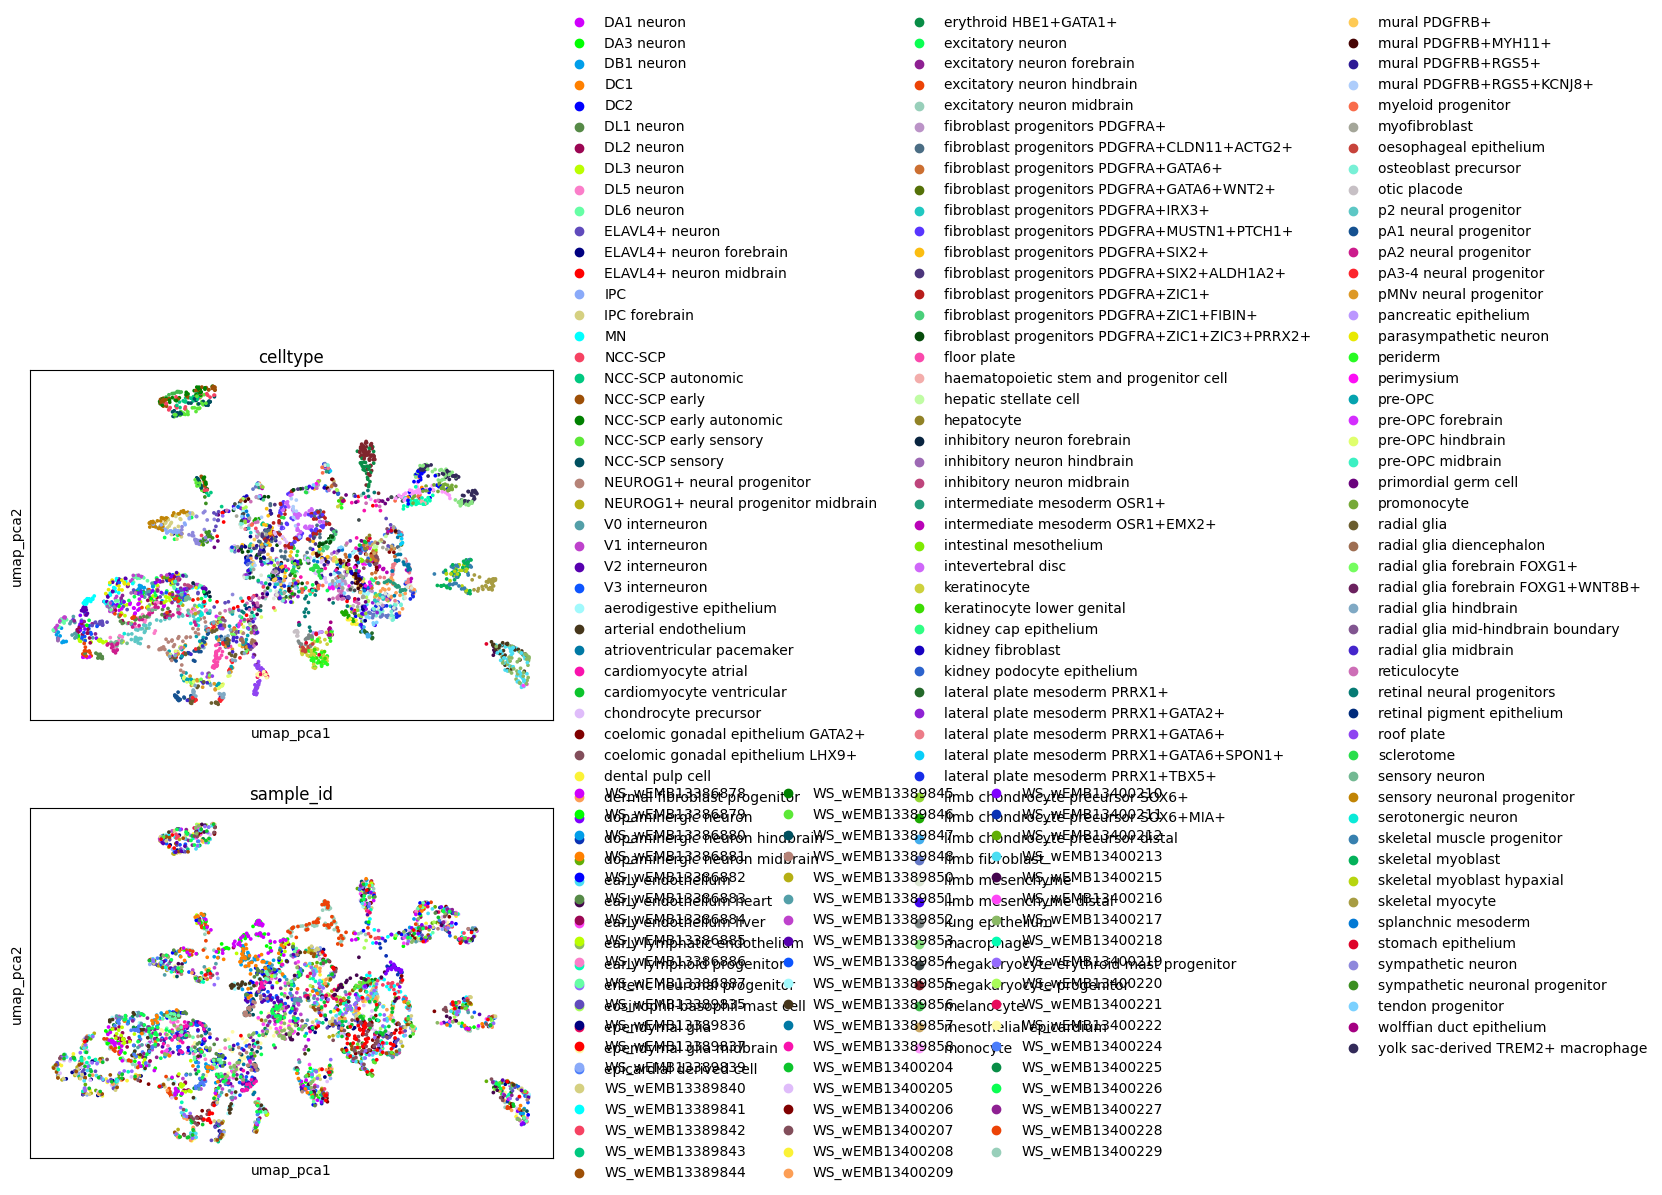

In [50]:
sc.pl.embedding(adata_hv_sum, basis="umap_pca", color=["celltype", "sample_id"], ncols=1, palette=palette)

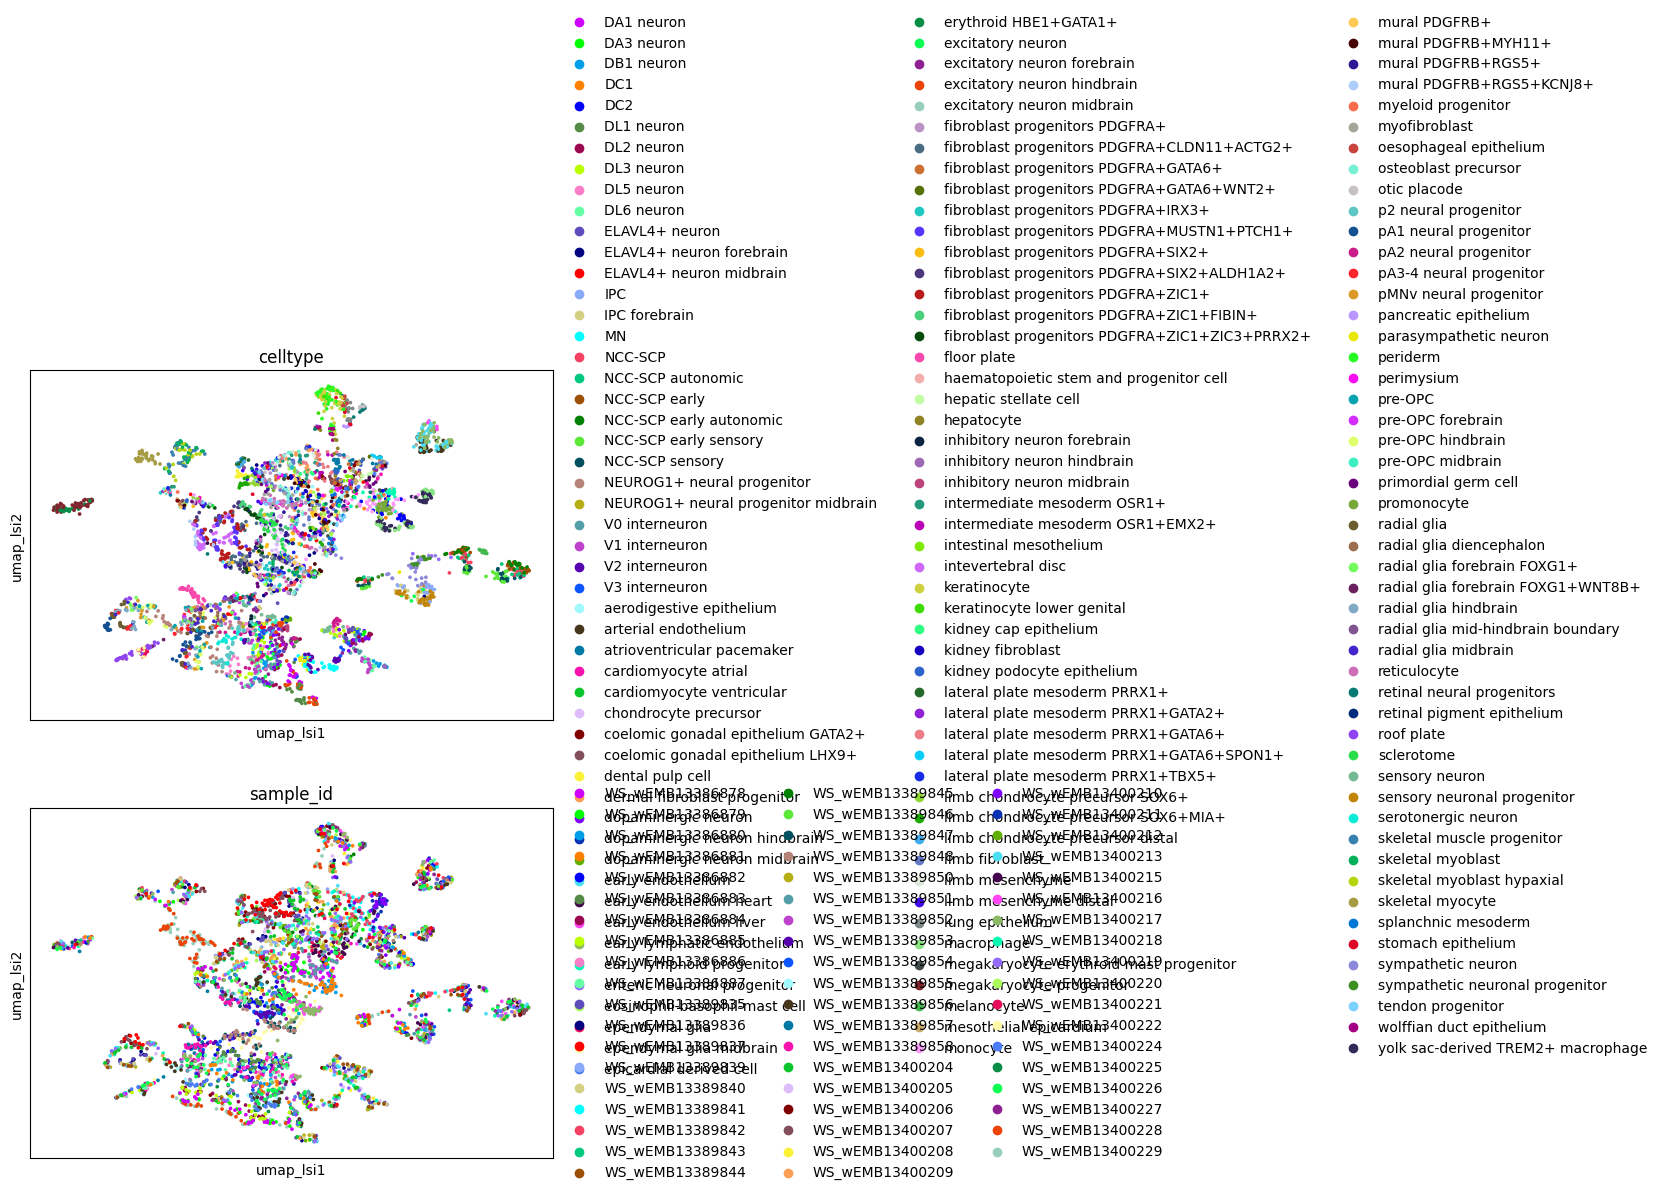

In [51]:
sc.pl.embedding(adata_hv_sum, basis="umap_lsi", color=["celltype", "sample_id"], ncols=1, palette=palette)

### MEAN

Normalise with TF-IDF

In [22]:
ac.pp.tfidf(adata_hv_mean, scale_factor=1e4, from_layer="mean", to_layer="tfidf_mean")

In [23]:
adata_hv_mean.X = adata_hv_mean.layers["tfidf_mean"]

Calculate LSI embedding

In [24]:
ac.tl.lsi(adata_hv_mean, n_comps=50)
# adata_hv_mean.obsm['X_lsi'] = adata_hv_mean.obsm['X_lsi'][:,1:]
# adata_hv_mean.varm["LSI"] = adata_hv_mean.varm["LSI"][:,1:]
# adata_hv_mean.uns["lsi"]["stdev"] = adata_hv_mean.uns["lsi"]["stdev"][1:]

Calculate PCA embedding

In [25]:
sc.pp.pca(adata_hv_mean, n_comps=50, layer="tfidf_mean")
# adata_hv_mean.obsm['pca_mean'] = adata_hv_mean.obsm['pca_mean'][:,2:]
# adata_hv_mean.varm["pca_mean"] = adata_hv_mean.varm["LSI"][:,2:]
# adata_hv_mean.uns["pca_mean"]["variance"] = adata_hv_mean.uns["pca_mean"]["variance"][2:]
# adata_hv_mean.uns["pca_mean"]["variance_ratio"] = adata_hv_mean.uns["pca_mean"]["variance_ratio"][2:]

Calculate KNN graphs

In [26]:
sc.pp.neighbors(adata_hv_mean, use_rep="X_lsi", key_added="neighbors_lsi")
sc.pp.neighbors(adata_hv_mean, use_rep="X_pca", key_added="neighbors_pca")

Calculate UMAP embeddings

In [27]:
sc.tl.umap(adata_hv_mean, neighbors_key="neighbors_lsi", key_added="umap_lsi")
sc.tl.umap(adata_hv_mean, neighbors_key="neighbors_pca", key_added="umap_pca")

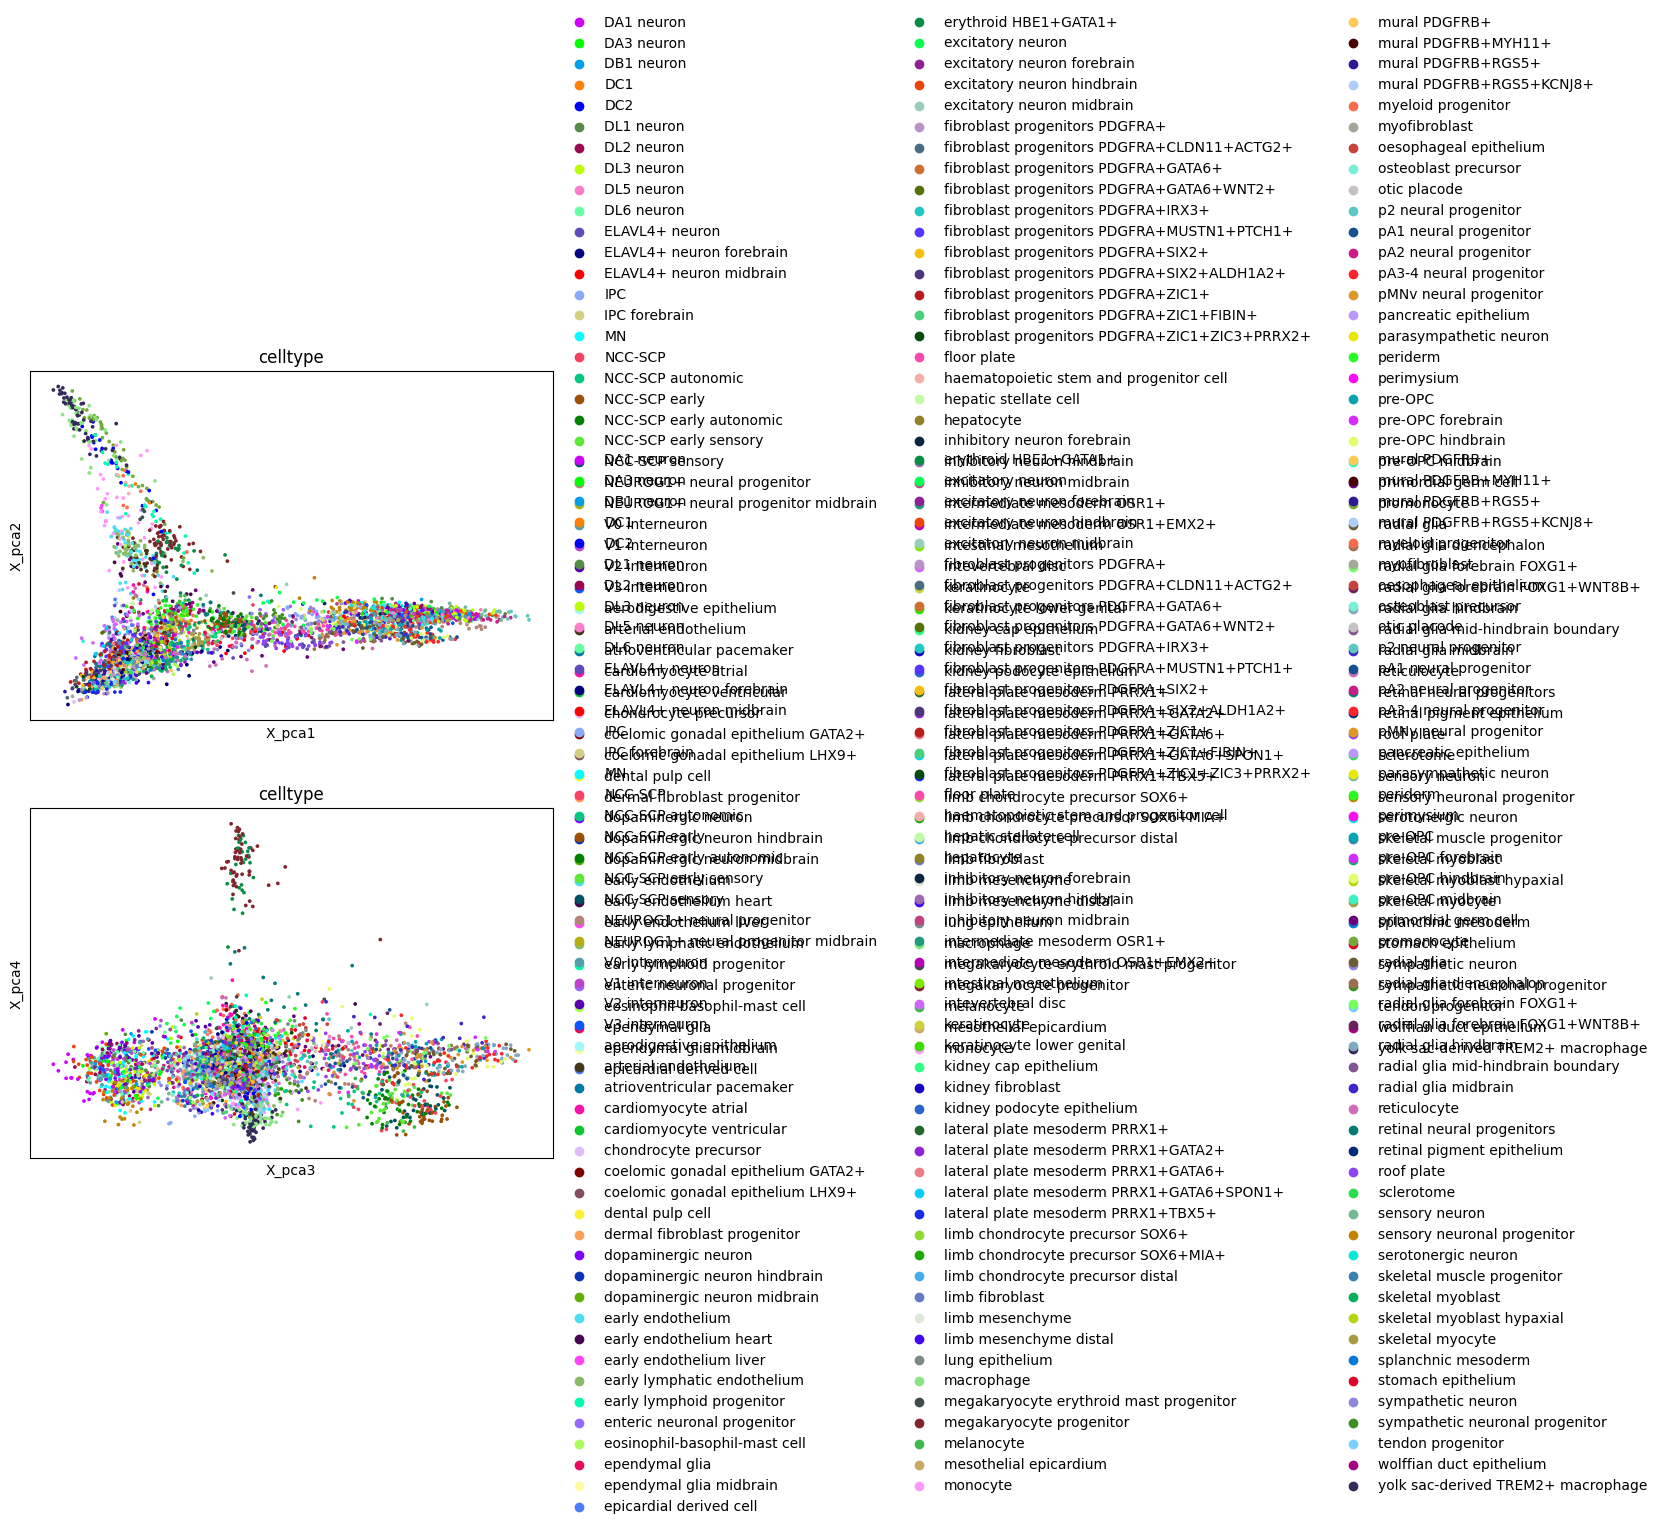

In [52]:
sc.pl.embedding(adata_hv_mean, basis="X_pca", color=["celltype"], ncols=1, components=["1,2", "3,4"], palette=palette)

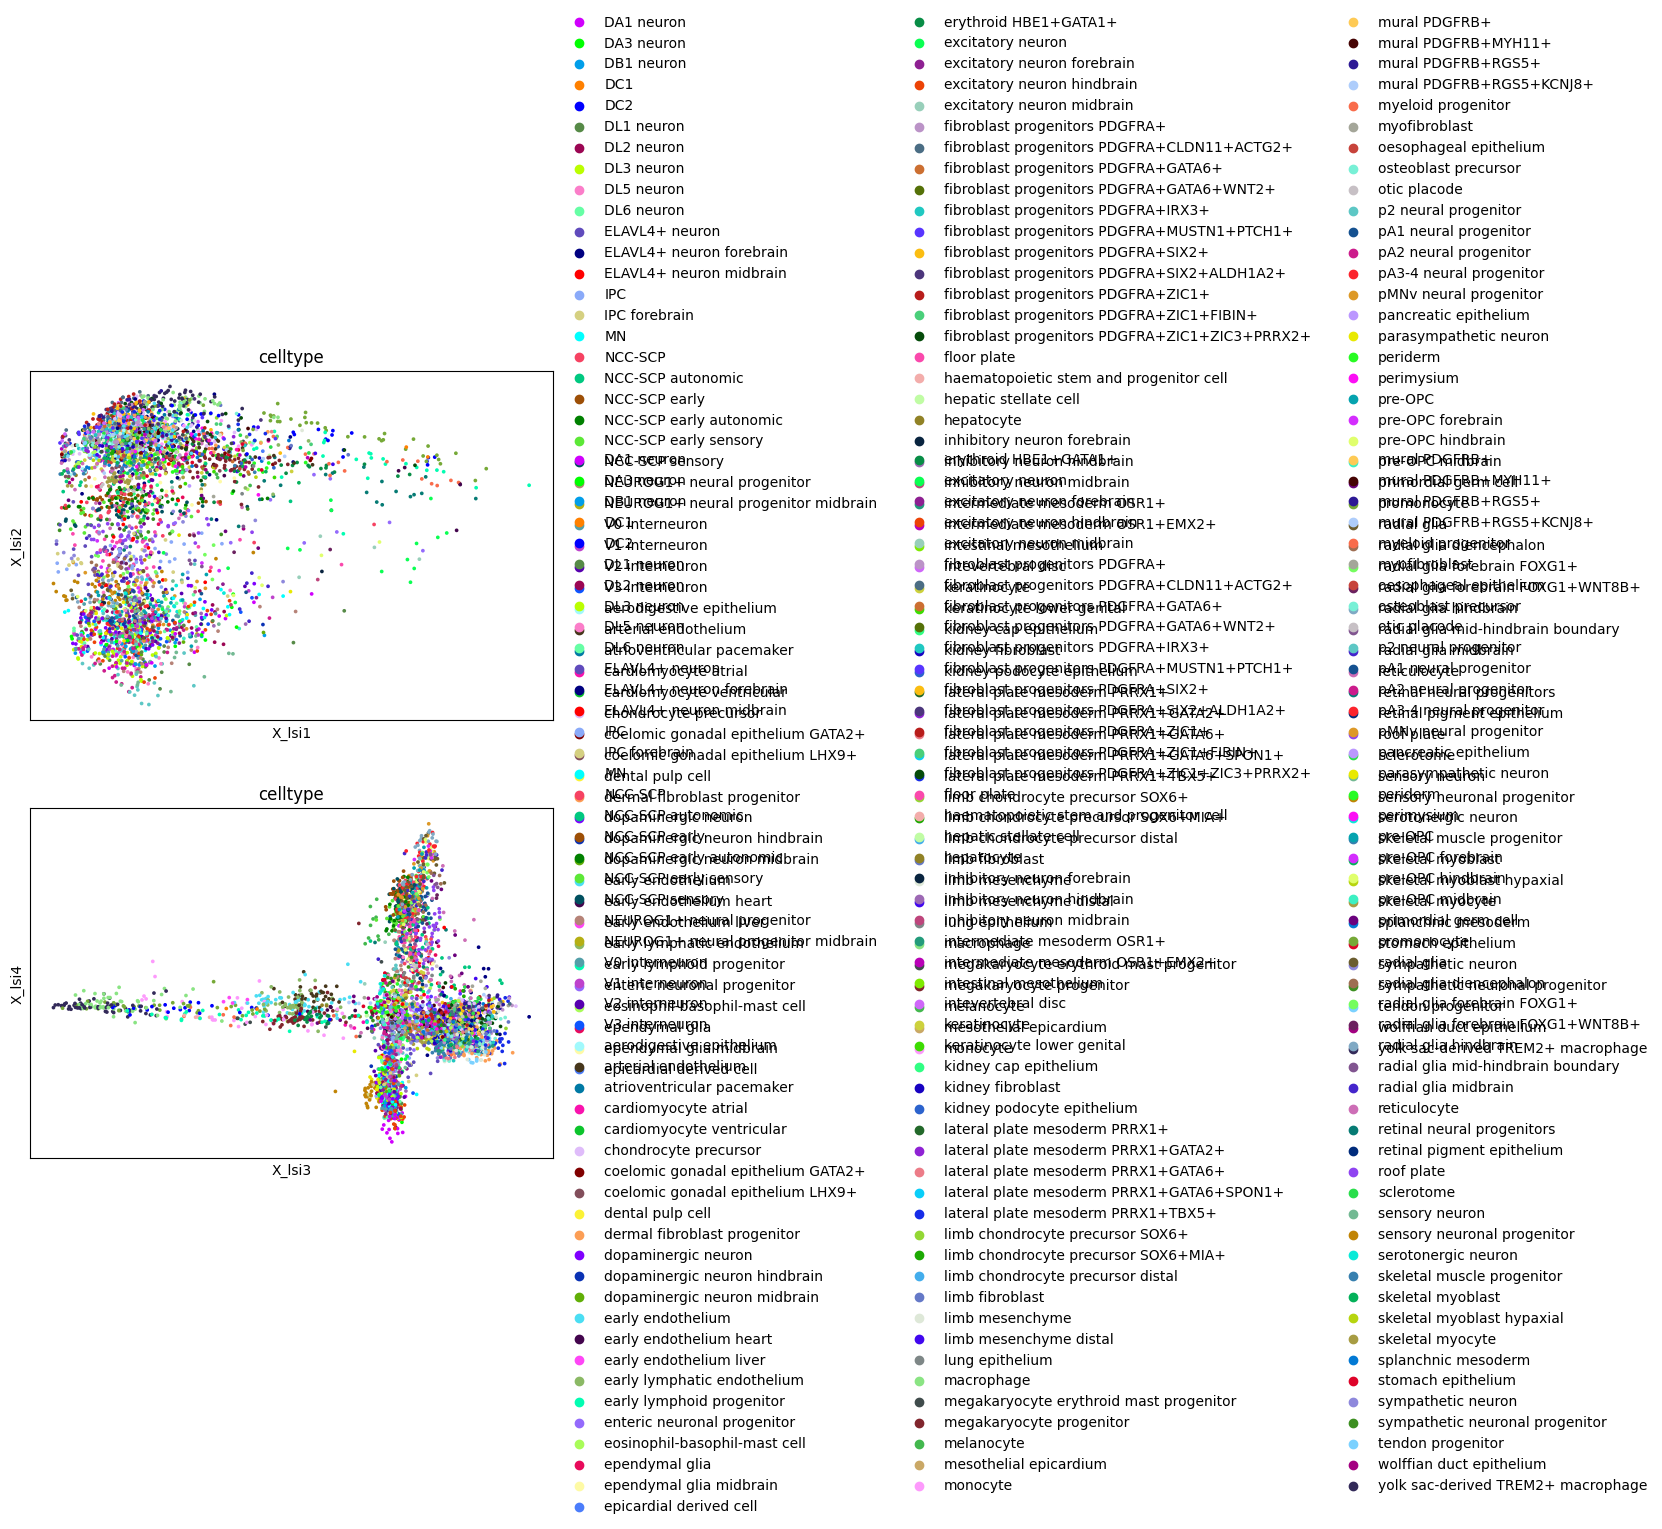

In [53]:
sc.pl.embedding(adata_hv_mean, basis="X_lsi", color=["celltype"], ncols=1, components=["1,2", "3,4"], palette=palette)

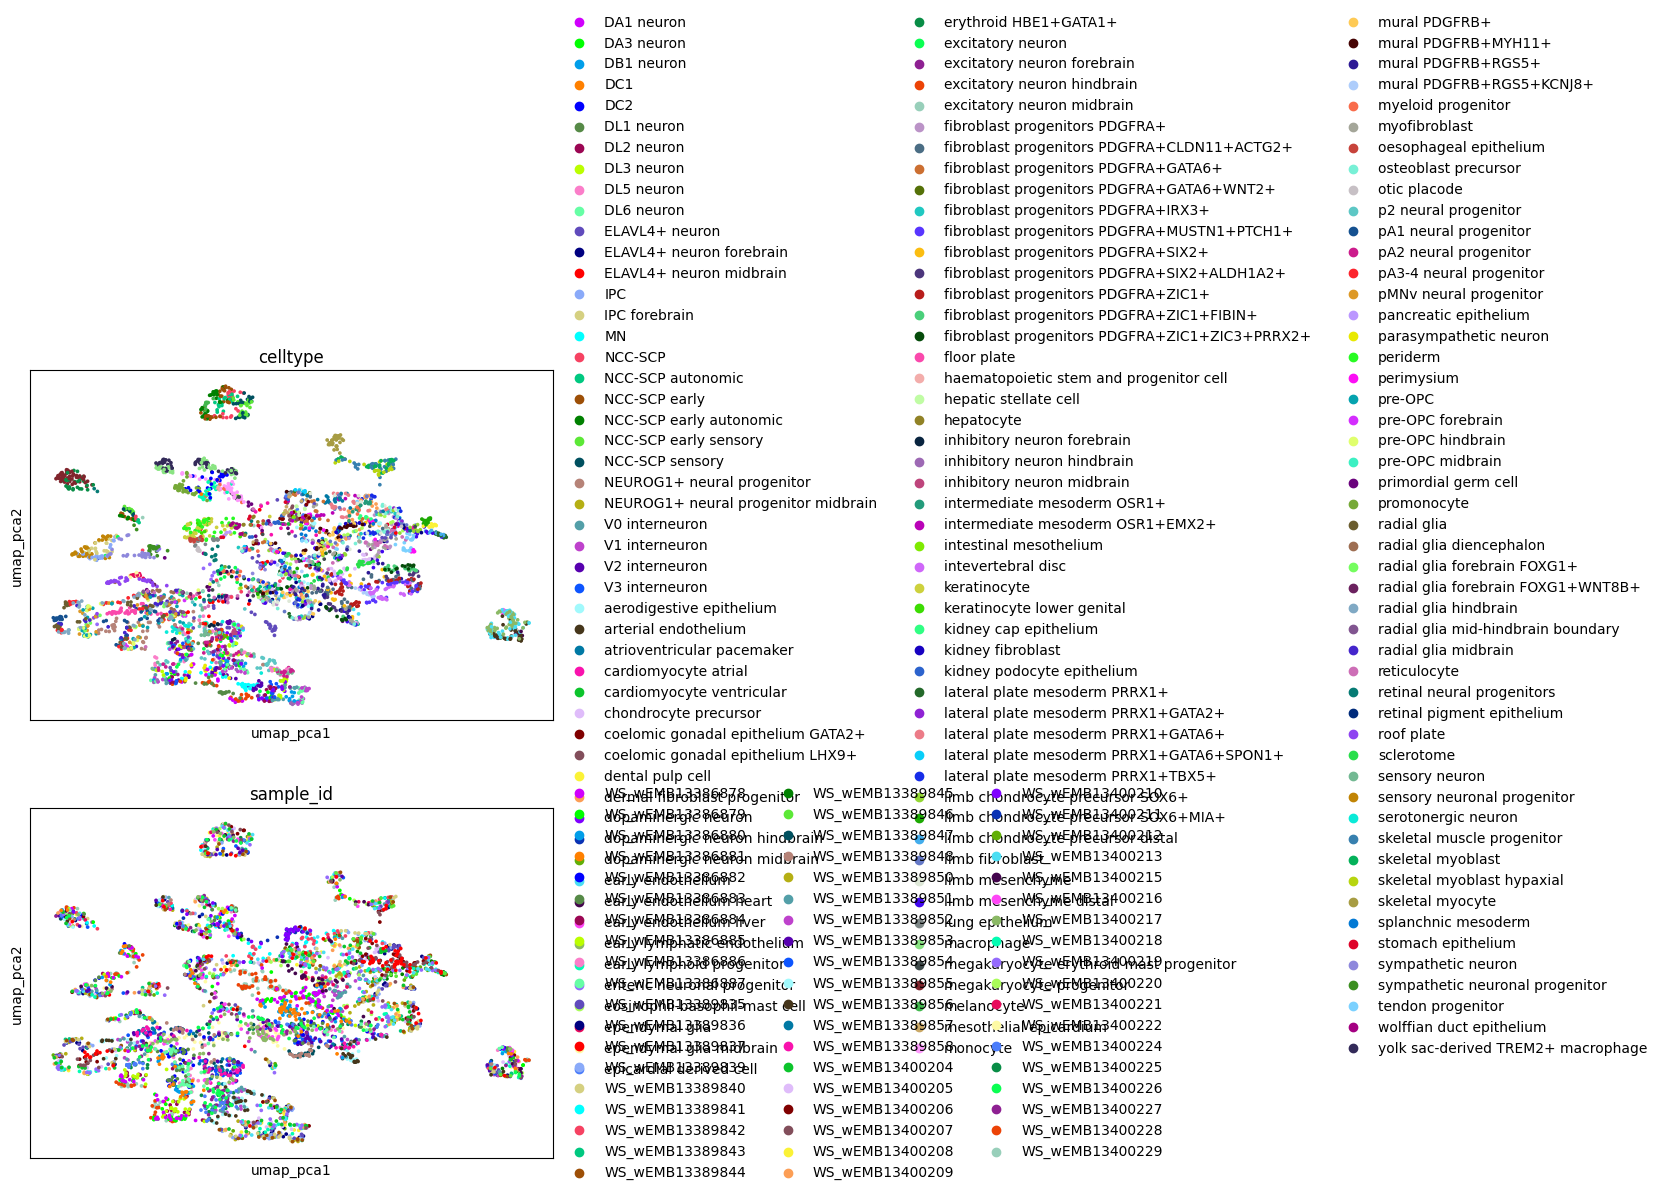

In [54]:
sc.pl.embedding(adata_hv_mean, basis="umap_pca", color=["celltype", "sample_id"], ncols=1, palette=palette)

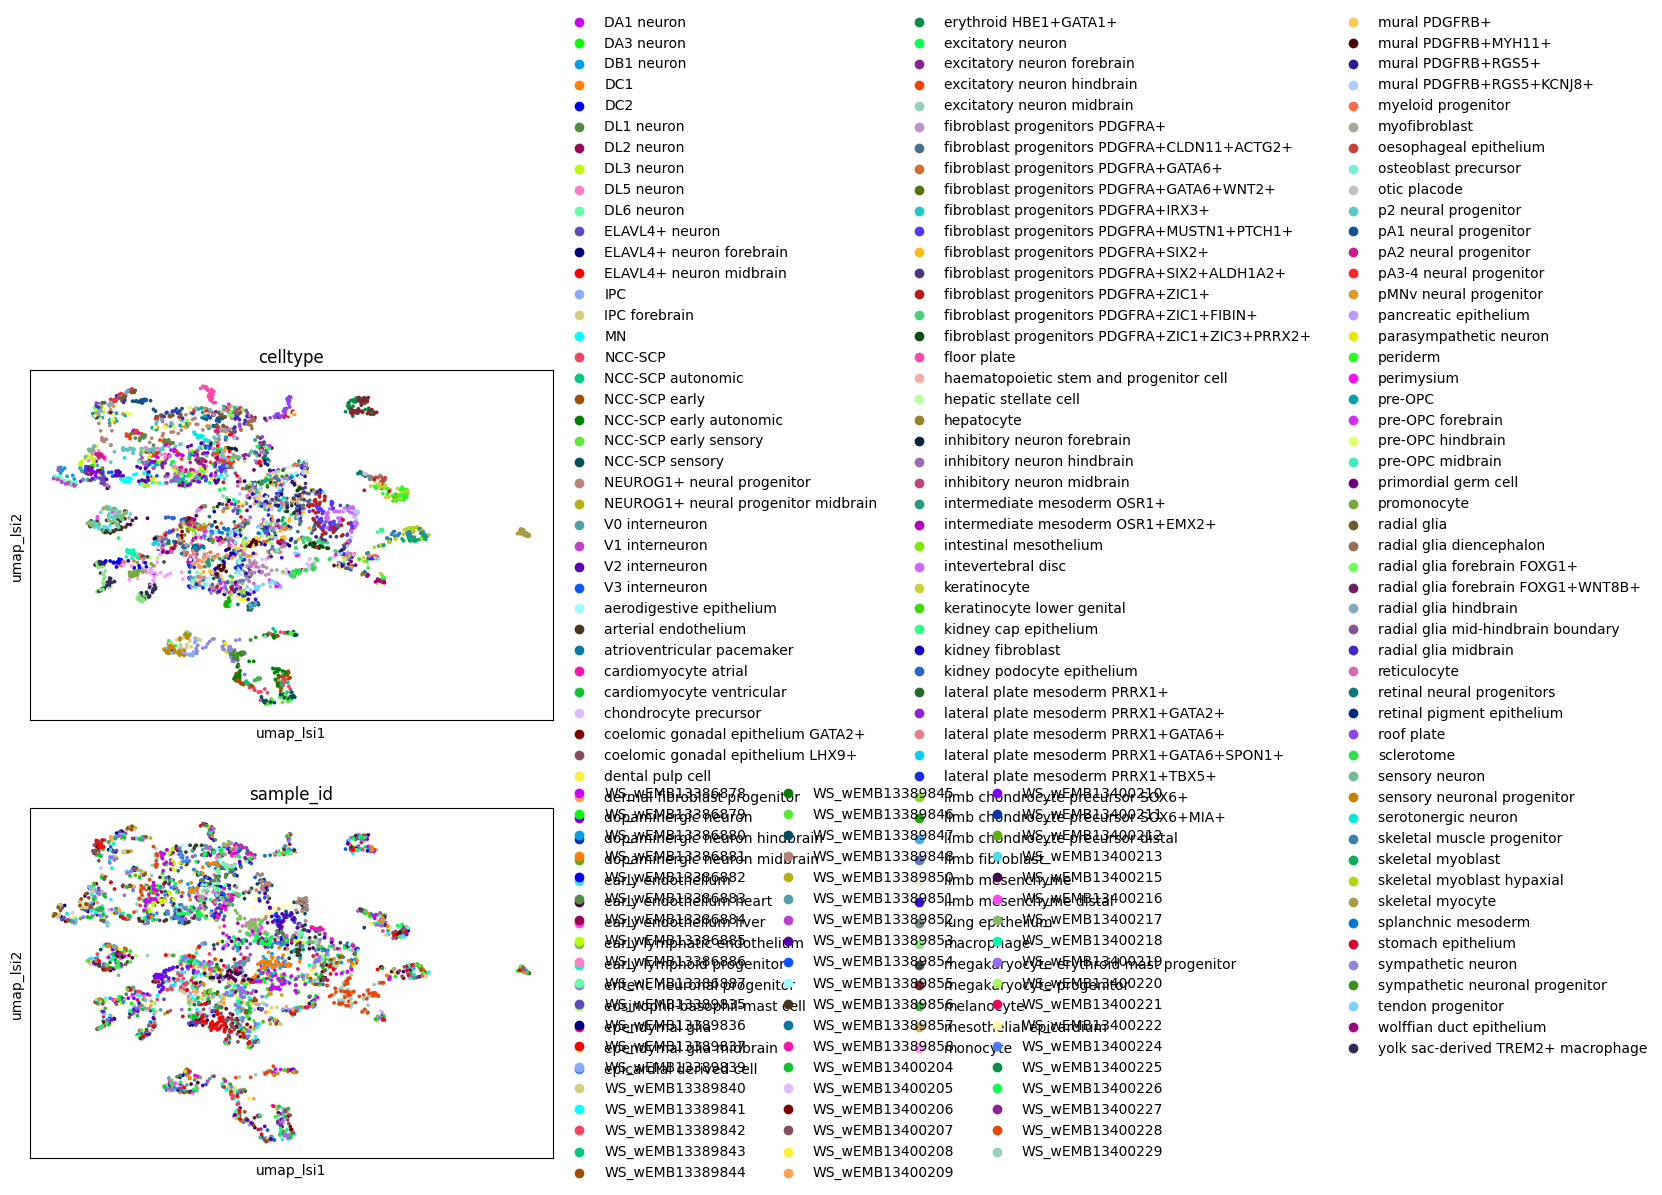

In [55]:
sc.pl.embedding(adata_hv_mean, basis="umap_lsi", color=["celltype", "sample_id"], ncols=1, palette=palette)

# Save results

In [32]:
adata.write_h5ad("results/pseudobulk/filtered.h5ad")
adata_hv_mean.write_h5ad("results/pseudobulk/lvl5/adata_hv_mean.h5ad")
adata_hv_sum.write_h5ad("results/pseudobulk/lvl5/adata_hv_sum.h5ad")